In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
CM_DIR = RESULTS_DIR / "confusion_matrices"
ROBUSTNESS_DIR = RESULTS_DIR / "robustness"
ERROR_DIR = RESULTS_DIR / "error_examples"

print("Project root:", PROJECT_ROOT)
print("Results dir exists:", RESULTS_DIR.exists())
print("Confusion matrix dir exists:", CM_DIR.exists())
print("Robustness dir exists:", ROBUSTNESS_DIR.exists())

Project root: /Users/amga/Desktop/umd/comp vision/MSML640final
Results dir exists: True
Confusion matrix dir exists: True
Robustness dir exists: True


## 1. Test Accuracies

In [22]:
test_accuracies = {
    "baseline": 0.6167,
    "augmentation": 0.6667,
    "synthetic": 0.7333,
    "synthetic_augmented": 0.6833,
}

test_df = pd.DataFrame([
    {"config": cfg, "test_accuracy": acc}
    for cfg, acc in test_accuracies.items()
])

test_df

,config,test_accuracy
0,baseline,0.6167
1,augmentation,0.6667
2,synthetic,0.7333
3,synthetic_augmented,0.6833


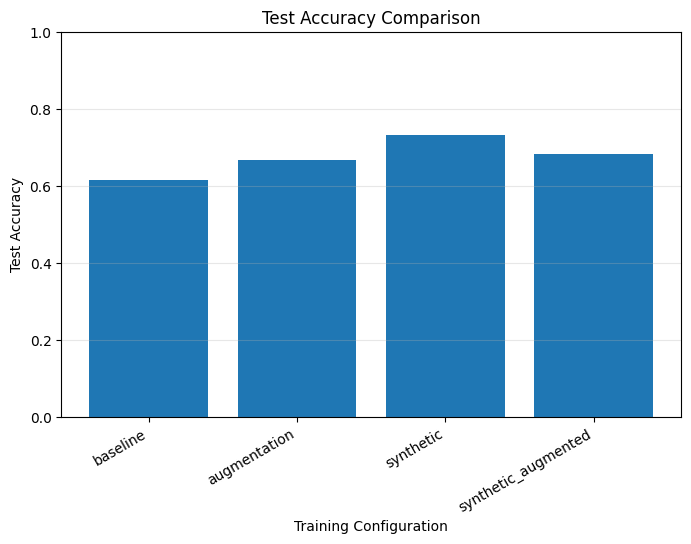

In [23]:
plot_df = test_df.dropna()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["config"], plot_df["test_accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Training Configuration")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [24]:
configs = ["baseline", "augmentation", "synthetic", "synthetic_augmented"]

for cfg in configs:
    path = CM_DIR / f"{cfg}_cm.png"
    print(cfg, path.exists(), path)

baseline True /Users/amga/Desktop/umd/comp vision/MSML640final/results/confusion_matrices/baseline_cm.png
augmentation True /Users/amga/Desktop/umd/comp vision/MSML640final/results/confusion_matrices/augmentation_cm.png
synthetic True /Users/amga/Desktop/umd/comp vision/MSML640final/results/confusion_matrices/synthetic_cm.png
synthetic_augmented True /Users/amga/Desktop/umd/comp vision/MSML640final/results/confusion_matrices/synthetic_augmented_cm.png


## 2. HeatMap Comparisons 

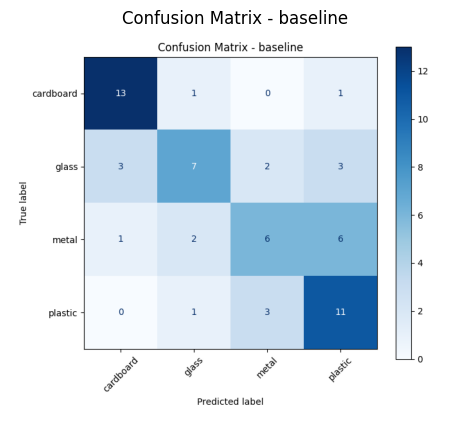

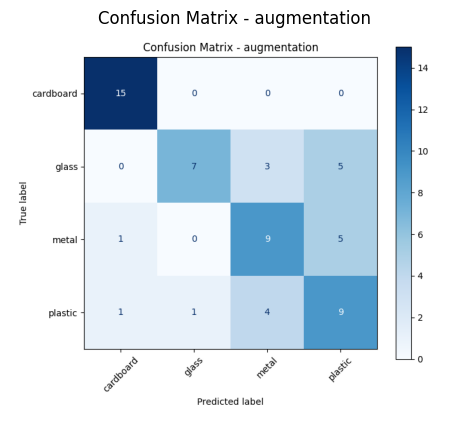

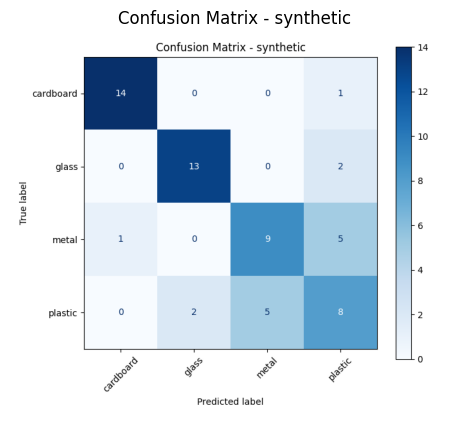

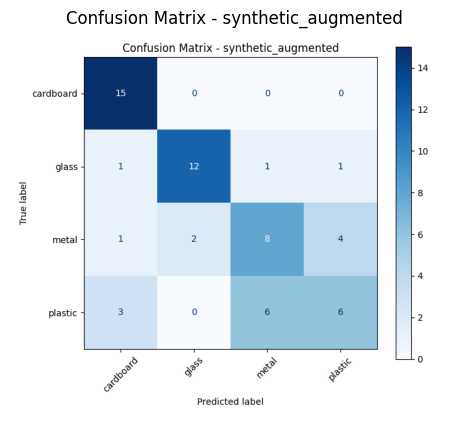

In [25]:
for cfg in configs:
    path = CM_DIR / f"{cfg}_cm.png"
    
    if path.exists():
        img = Image.open(path)
        plt.figure(figsize=(6, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Confusion Matrix - {cfg}")
        plt.show()
    else:
        print(f"Missing confusion matrix for {cfg}")

## 3. Robustness comparison based on accuracy

In [26]:
robustness_frames = []

for cfg in configs:
    csv_path = ROBUSTNESS_DIR / f"{cfg}_robustness_results.csv"
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        robustness_frames.append(df)
        
    else:
        print("Missing:", csv_path)

if robustness_frames:
    robustness_df = pd.concat(robustness_frames, ignore_index=True)
else:
    robustness_df = pd.DataFrame()

if len(robustness_df) > 0:
    pivot_robustness = robustness_df.pivot(
        index="perturbation",
        columns="model",
        values="accuracy"
    )
    display(pivot_robustness)

model,augmentation,baseline,synthetic,synthetic_augmented
perturbation,,,,
blur,0.5000,0.4833,0.7000,0.6833
bright,0.6167,0.4500,0.6000,0.6167
clean,0.6667,0.6167,0.7333,0.6833
dark,0.5667,0.5000,0.5500,0.5833
noise,0.4667,0.5167,0.5167,0.4500
occlusion,0.6000,0.5667,0.6833,0.6000


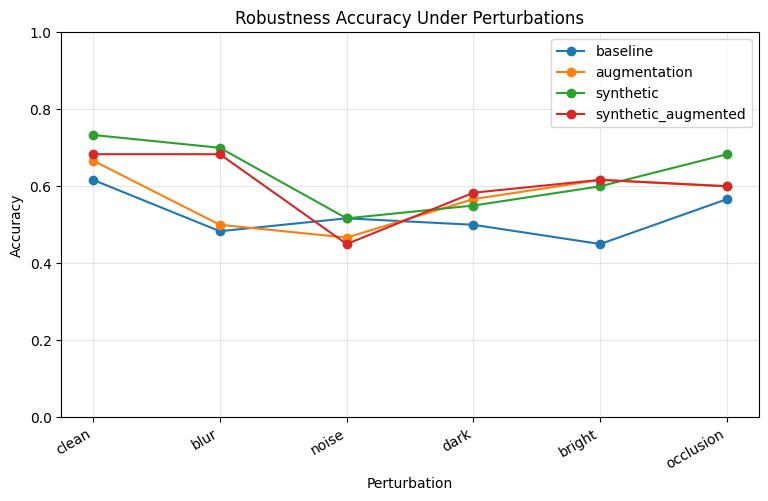

In [27]:
if len(robustness_df) > 0:
    plt.figure(figsize=(9, 5))

    for model_name in robustness_df["model"].unique():
        subset = robustness_df[robustness_df["model"] == model_name]
        plt.plot(
            subset["perturbation"],
            subset["accuracy"],
            marker="o",
            label=model_name
        )

    plt.title("Robustness Accuracy Under Perturbations")
    plt.xlabel("Perturbation")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No robustness results to plot.")

# Accuracy drops

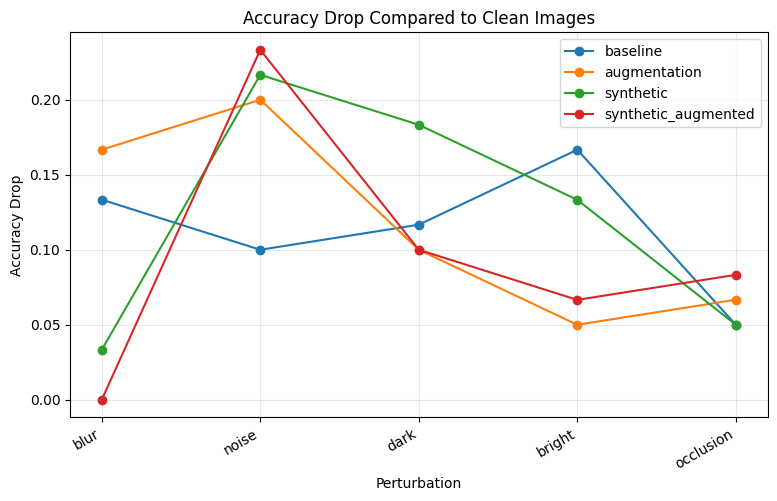

In [29]:
if len(robustness_df) > 0:
    plot_drop_df = drop_df[drop_df["perturbation"] != "clean"]

    plt.figure(figsize=(9, 5))

    for model_name in plot_drop_df["model"].unique():
        subset = plot_drop_df[plot_drop_df["model"] == model_name]
        plt.plot(
            subset["perturbation"],
            subset["accuracy_drop"],
            marker="o",
            label=model_name
        )

    plt.title("Accuracy Drop Compared to Clean Images")
    plt.xlabel("Perturbation")
    plt.ylabel("Accuracy Drop")
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No accuracy drop data.")

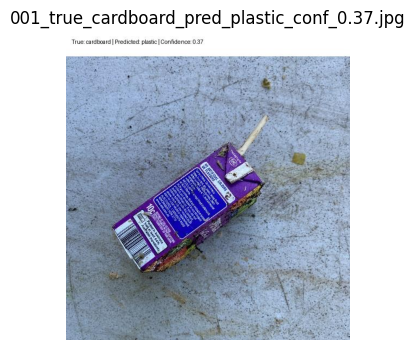

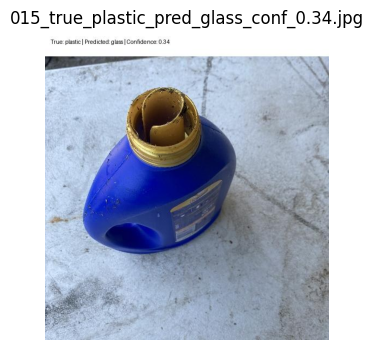

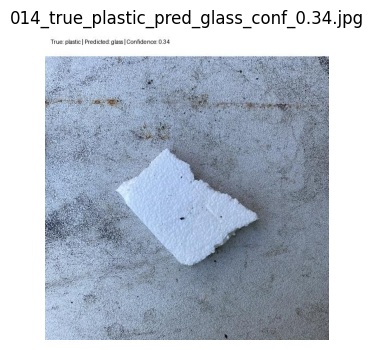

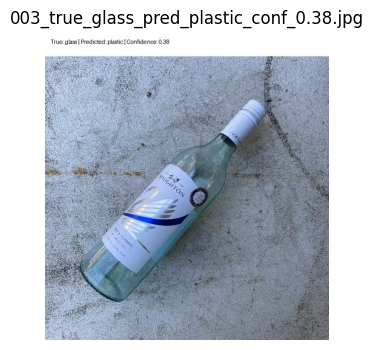

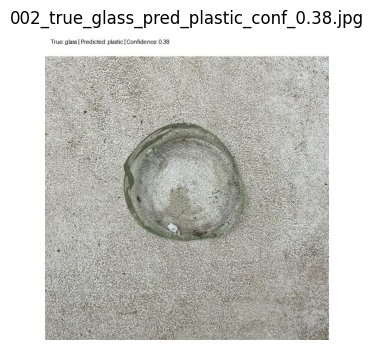

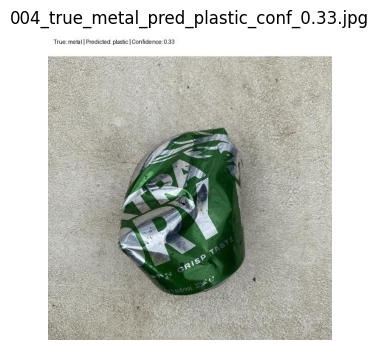

In [30]:
selected_model = "synthetic"
selected_error_dir = ERROR_DIR / selected_model

if selected_error_dir.exists():
    error_images = list(selected_error_dir.glob("*.jpg"))[:6]

    if len(error_images) == 0:
        print("No error example images found.")
    else:
        for img_path in error_images:
            img = Image.open(img_path)
            plt.figure(figsize=(5, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(img_path.name)
            plt.show()
else:
    print(f"No error directory found for {selected_model}.")

## Evaluation Interpretation

The synthetic model achieved the best test accuracy, suggesting that synthetic image transformations improved generalization. The synthetic_augmented model had strong validation accuracy but lower test accuracy than the synthetic only model. This means that combining too much augmentation with synthetic data may create a distribution mismatch between training and test data. The robustness evaluation helps show how each model performs under blur, noise, brightness changes, darkness, and occlusion as well.